In [1]:
import torch
import torchvision
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from torchinfo import summary
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
df = pd.read_csv('Data_Entry_2017.csv')
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
df.shape

(112120, 12)

In [5]:
df['Finding Labels'].nunique()

836

In [9]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class ChestXrayDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        
        self.all_labels = sorted(list(set([label for sublist in self.df['Finding Labels'].str.split('|') for label in sublist])))
        
        self.label_to_idx = {label: i for i, label in enumerate(self.all_labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        label_list = self.df.iloc[idx]['Finding Labels'].split('|')
        target = torch.zeros(len(self.all_labels))
        for label in label_list:
            if label in self.label_to_idx:
                target[self.label_to_idx[label]] = 1.0
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224

my_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])



train_df,test_df = train_test_split(df, test_size = 0.1, random_state=42)
train_df.reset_index(drop = True, inplace = True)
test_df.reset_index(drop = True, inplace = True)
train_df.to_csv('train_df_full.csv', index = False)
test_df.to_csv('test_df_full.csv', index = False)

train_dataset = ChestXrayDataset(
    csv_path='train_df_full.csv',
    img_dir='images_all', 
    transform=my_transforms
)
test_dataset = ChestXrayDataset(
    csv_path='test_df_full.csv',
    img_dir='images_all', 
    transform=my_transforms
)

dataset = ChestXrayDataset(
    csv_path='Data_Entry_2017.csv',
    img_dir='images_all', 
    transform=my_transforms
)

print(f"Detected {len(train_dataset.all_labels)} classes: {train_dataset.all_labels}")
print(f"Manually created transforms: {my_transforms}")

print(f"Detected {len(test_dataset.all_labels)} classes: {test_dataset.all_labels}")
print(f"Manually created transforms: {my_transforms}")

Detected 15 classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Detected 15 classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [11]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
next(iter(test_dataloader))

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.00

In [13]:
individual_labels = df['Finding Labels'].str.split('|')
class_counts = individual_labels.explode().value_counts()
print(class_counts)

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64


### Preprocess data

In [14]:
image_batch, label_batch = next(iter(train_dataloader))

image, label = image_batch[0], label_batch[0]

image.shape, label

(torch.Size([3, 224, 224]),
 tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

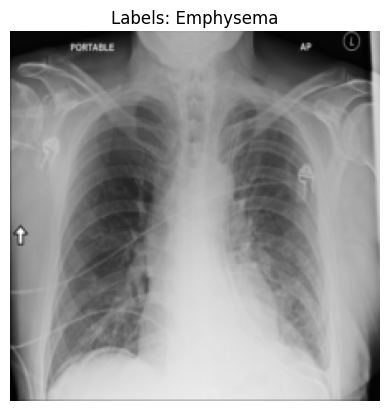

In [15]:
class_names = train_dataset.all_labels
plt.imshow(image.permute(1, 2, 0))
active_labels = [class_names[i] for i, val in enumerate(label) if val == 1]
plt.title(f"Labels: {', '.join(active_labels)}")
plt.axis(False);

### Patch Embedding

In [16]:
rand_image_tensor = torch.randn(32, 3, 224, 224) 
rand_image_tensor.shape

torch.Size([32, 3, 224, 224])

In [17]:

class PatchEmbedding(nn.Module):
    def __init__(self, 
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=512):
        super().__init__()
        self.patch_size = patch_size
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        self.flatten = nn.Flatten(start_dim=2, 
                                  end_dim=3)
        
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, f"Input image size must be divisble by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched) 
        
        return x_flattened.permute(0, 2, 1) 

In [18]:
patch_embedding = PatchEmbedding(patch_size=16)
patch_embedding_output = patch_embedding(rand_image_tensor)
print(f"Input shape: {rand_image_tensor.shape}")
print(f"Output shape: {patch_embedding_output.shape} -> (batch_size, num_patches, embedding_dim)") 

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 196, 512]) -> (batch_size, num_patches, embedding_dim)


### 2. TransformerEncoderLayer 

In [19]:
transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=512,
                                                       nhead=8,
                                                       dim_feedforward=1024,
                                                       dropout=0.1,
                                                       activation="gelu",
                                                       batch_first=True,
                                                       norm_first=True)
transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (linear1): Linear(in_features=512, out_features=1024, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=1024, out_features=512, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [20]:
from torchinfo import summary 

summary(model=transformer_encoder_layer,
        input_size=patch_embedding_output.shape)

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoderLayer                  [32, 196, 512]            --
├─LayerNorm: 1-1                         [32, 196, 512]            1,024
├─MultiheadAttention: 1-2                [32, 196, 512]            1,050,624
├─Dropout: 1-3                           [32, 196, 512]            --
├─LayerNorm: 1-4                         [32, 196, 512]            1,024
├─Linear: 1-5                            [32, 196, 1024]           525,312
├─Dropout: 1-6                           [32, 196, 1024]           --
├─Linear: 1-7                            [32, 196, 512]            524,800
├─Dropout: 1-8                           [32, 196, 512]            --
Total params: 2,102,784
Trainable params: 2,102,784
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 33.67
Input size (MB): 12.85
Forward/backward pass size (MB): 128.45
Params size (MB): 4.21
Estimated Total Size (MB): 145.50

### 3. Stack Transformer Encoder Layers on top of each other

In [21]:
transformer_encoder = nn.TransformerEncoder(
    encoder_layer=transformer_encoder_layer,
    num_layers=3)

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [22]:
summary(model=transformer_encoder,
        input_size=patch_embedding_output.shape)

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoder                       [32, 196, 512]            --
├─ModuleList: 1-1                        --                        --
│    └─TransformerEncoderLayer: 2-1      [32, 196, 512]            --
│    │    └─LayerNorm: 3-1               [32, 196, 512]            1,024
│    │    └─MultiheadAttention: 3-2      [32, 196, 512]            1,050,624
│    │    └─Dropout: 3-3                 [32, 196, 512]            --
│    │    └─LayerNorm: 3-4               [32, 196, 512]            1,024
│    │    └─Linear: 3-5                  [32, 196, 1024]           525,312
│    │    └─Dropout: 3-6                 [32, 196, 1024]           --
│    │    └─Linear: 3-7                  [32, 196, 512]            524,800
│    │    └─Dropout: 3-8                 [32, 196, 512]            --
│    └─TransformerEncoderLayer: 2-2      [32, 196, 512]            --
│    │    └─LayerNorm: 3-9               [32, 196, 512]       

### 5. Put it all together and create ViT 

We're skipping step 4, so that can be incorported the into the overall ViT architecture.

In [23]:
class ViT(nn.Module): 
  def __init__(self,
               img_size=224, 
               num_channels=3,
               patch_size=16,
               embedding_dim=512, 
               dropout=0.1, 
               mlp_size=1024, 
               num_transformer_layers=3, 
               num_heads=8, 
               num_classes=15): 
    super().__init__()

    assert img_size % patch_size == 0, "Image size must be divisble by patch size."

    self.patch_embedding = PatchEmbedding(in_channels=num_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim),
                                    requires_grad=True)

    num_patches = (img_size * img_size) // patch_size**2 # N = HW/P^2
    self.positional_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))

    self.embedding_dropout = nn.Dropout(p=dropout)

    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                                                              nhead=num_heads,
                                                                                              dim_feedforward=mlp_size,
                                                                                              activation="gelu",
                                                                                              batch_first=True,
                                                                                              norm_first=True), 
                                                     num_layers=num_transformer_layers) 

    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features=num_classes)
    )

  def forward(self, x):
    
    batch_size = x.shape[0]
    x = self.patch_embedding(x)
    class_token = self.class_token.expand(batch_size, -1, -1)
    x = torch.cat((class_token, x), dim=1)
    x = self.positional_embedding + x
    x = self.embedding_dropout(x)
    x = self.transformer_encoder(x)
    x = self.mlp_head(x[:, 0])

    return x

In [24]:
demo_img = image.to(device)
if len(demo_img.shape) == 3:
    demo_img = demo_img.unsqueeze(0)
    print(demo_img.shape) 
vit = ViT(num_classes=len(class_names)).to(device)
vit(demo_img)

torch.Size([1, 3, 224, 224])


tensor([[-0.3419, -0.1719, -0.4490,  0.3324, -0.2163,  0.0617, -0.5059,  0.2557,
          0.2676, -0.6741,  1.2246,  0.7557, -0.0046,  0.6645, -0.2227]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [25]:
summary(model=ViT(num_classes=15),
        input_size=demo_img.shape)

Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [1, 15]                   101,376
├─PatchEmbedding: 1-1                         [1, 196, 512]             --
│    └─Conv2d: 2-1                            [1, 512, 14, 14]          393,728
│    └─Flatten: 2-2                           [1, 512, 196]             --
├─Dropout: 1-2                                [1, 197, 512]             --
├─TransformerEncoder: 1-3                     [1, 197, 512]             --
│    └─ModuleList: 2-3                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 197, 512]             2,102,784
│    │    └─TransformerEncoderLayer: 3-2      [1, 197, 512]             2,102,784
│    │    └─TransformerEncoderLayer: 3-3      [1, 197, 512]             2,102,784
├─Sequential: 1-4                             [1, 15]                   --
│    └─LayerNorm: 2-4                         [1, 512]          

In [26]:
len(class_names)

15

In [27]:
model = ViT(num_classes=len(dataset.all_labels)).to(device)
pos_weight = torch.tensor([10.0] * 15).to(device) 
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
epochs = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

In [28]:
import torch
from tqdm.auto import tqdm

def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_logits = model(X)
        loss = loss_fn(y_logits, y.float())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss / len(dataloader)

def test_step(model, dataloader, loss_fn, device):
    # Set the model to evaluation mode (turns off Dropout/Batchnorm)
    model.eval()
    test_loss = 0

    # Turn off gradient tracking to save memory and compute
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_logits = model(X)

            # 2. Calculate loss
            loss = loss_fn(test_logits, y.float())
            test_loss += loss.item()

    # Return the average loss over the entire dataloader
    return test_loss / len(dataloader)

In [29]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                             recall_score, accuracy_score, roc_curve, 
                             matthews_corrcoef)

def evaluate_and_save_all(model, dataloader, device, class_names, epoch, train_losses, val_losses, optimizer):
    model.eval()
    all_labels, all_probs = [], []
    
    # Create directory structure
    epoch_dir = f"metrics/epoch_{epoch}"
    os.makedirs(epoch_dir, exist_ok=True)

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            probs = torch.sigmoid(logits)
            all_labels.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs = np.vstack(all_probs)
    all_preds = (all_probs > 0.2).astype(int) # Using 0.2 threshold for better sensitivity

    metrics_per_class = {}
    mcc_scores = []

    # 1. Plot ROC Curves
    plt.figure(figsize=(12, 8))
    for i, class_name in enumerate(class_names):
        try:
            auc_val = roc_auc_score(all_labels[:, i], all_probs[:, i])
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
            mcc = matthews_corrcoef(all_labels[:, i], all_preds[:, i])
        except ValueError:
            auc_val, mcc, fpr, tpr = 0.5, 0.0, [0, 1], [0, 1]

        mcc_scores.append(mcc)
        metrics_per_class[class_name] = {
            "AUROC": float(auc_val),
            "F1": float(f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)),
            "Precision": float(precision_score(all_labels[:, i], all_preds[:, i], zero_division=0)),
            "Recall": float(recall_score(all_labels[:, i], all_preds[:, i], zero_division=0)),
            "Accuracy": float(accuracy_score(all_labels[:, i], all_preds[:, i])),
            "MCC": float(mcc)
        }
        plt.plot(fpr, tpr, label=f'{class_name} ({auc_val:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f"ROC Curves - Epoch {epoch}")
    plt.legend(loc="lower right", fontsize='x-small', ncol=2)
    plt.savefig(f"{epoch_dir}/roc_curves.png")
    plt.close()

    # 2. Plot MCC Graph
    plt.figure(figsize=(12, 6))
    plt.bar(class_names, mcc_scores, color='darkslateblue')
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Matthews Correlation Coefficient - Epoch {epoch}")
    plt.ylabel("MCC Score")
    plt.savefig(f"{epoch_dir}/mcc_graph.png")
    plt.close()

    # 3. Plot Loss Graph
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f"Training vs Validation Loss - Epoch {epoch}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{epoch_dir}/loss_graph.png")
    plt.close()

    # 4. Save JSON Metrics
    with open(f"{epoch_dir}/metrics.json", "w") as f:
        json.dump(metrics_per_class, f, indent=4)

    # 5. Save Model Checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics_per_class
    }, f"{epoch_dir}/model_checkpoint.pth")

    return metrics_per_class

In [ ]:
# for epoch in tqdm(range(100)):
    
#     avg_train_loss = train_step(model, train_dataloader, loss_fn, optimizer, device)
    
    
#     stats = evaluate_model_with_curves(model, test_dataloader, device, dataset.all_labels, epoch+1)
    
#     print(f"\nEpoch {epoch+1} | Loss: {avg_train_loss:.4f}")
#     print(stats)

train_loss_history = []
val_loss_history = []

for epoch in tqdm(range(100)):
    current_epoch = epoch + 1
    
    # Training Phase
    avg_train_loss = train_step(model, train_dataloader, loss_fn, optimizer, device)
    train_loss_history.append(avg_train_loss)
    
    # Validation Phase (to get val_loss for the graph)
    avg_val_loss = test_step(model, test_dataloader, loss_fn, device)
    val_loss_history.append(avg_val_loss)
    
    # Evaluation, Saving Graphs, JSON, and Model
    stats = evaluate_and_save_all(
        model=model,
        dataloader=test_dataloader,
        device=device,
        class_names=dataset.all_labels,
        epoch=current_epoch,
        train_losses=train_loss_history,
        val_losses=val_loss_history,
        optimizer=optimizer
    )
    
    print(f"\nEpoch {current_epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    # Display No Finding MCC as a quick progress check
    if 'No Finding' in stats:
        print(f"No Finding MCC: {stats['No Finding']['MCC']:.3f}")

  0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.8305 | Val Loss: 0.8098
No Finding MCC: 0.000

Epoch 2 | Train Loss: 0.8203 | Val Loss: 0.8024
No Finding MCC: 0.000

Epoch 3 | Train Loss: 0.8128 | Val Loss: 0.7968
No Finding MCC: 0.000

Epoch 4 | Train Loss: 0.8070 | Val Loss: 0.8020
No Finding MCC: 0.000

Epoch 5 | Train Loss: 0.8031 | Val Loss: 0.7996
No Finding MCC: 0.000

Epoch 6 | Train Loss: 0.7984 | Val Loss: 0.7894
No Finding MCC: 0.000


In [30]:
checkpoint_path = "metrics/epoch_6/model_checkpoint.pth"

checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] # This will be 6

print(f"Resuming from Epoch {start_epoch}")

Resuming from Epoch 6


C:\Users\user\AppData\Local\Temp\ipykernel_18588\559674393.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [31]:
train_loss_history = [0.8305, 0.8203, 0.8128, 0.8070, 0.8031, 0.7984]
val_loss_history = [0.8098, 0.8024, 0.7968, 0.8020, 0.7996, 0.7894]

In [32]:
start_epoch = 6

for epoch in tqdm(range(start_epoch, 100)):
    current_epoch = epoch + 1
    
    # --- TRAINING ---
    avg_train_loss = train_step(model, train_dataloader, loss_fn, optimizer, device)
    train_loss_history.append(avg_train_loss)
    
    # --- VALIDATION ---
    avg_val_loss = test_step(model, test_dataloader, loss_fn, device)
    val_loss_history.append(avg_val_loss)
    
    # --- FULL SAVING (Graphs, JSON, Model) ---
    stats = evaluate_and_save_all(
        model=model,
        dataloader=test_dataloader,
        device=device,
        class_names=dataset.all_labels,
        epoch=current_epoch,
        train_losses=train_loss_history,
        val_losses=val_loss_history,
        optimizer=optimizer
    )
    
    # --- PROGRESS CHECK ---
    print(f"\nEpoch {current_epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if 'No Finding' in stats:
        print(f"No Finding - AUROC: {stats['No Finding']['AUROC']:.3f} | MCC: {stats['No Finding']['MCC']:.3f}")

  0%|          | 0/94 [00:00<?, ?it/s]


Epoch 7 | Train Loss: 0.7952 | Val Loss: 0.7889
No Finding - AUROC: 0.701 | MCC: 0.000

Epoch 8 | Train Loss: 0.7915 | Val Loss: 0.7831
No Finding - AUROC: 0.697 | MCC: 0.000

Epoch 9 | Train Loss: 0.7887 | Val Loss: 0.7811
No Finding - AUROC: 0.702 | MCC: 0.000

Epoch 10 | Train Loss: 0.7862 | Val Loss: 0.7837
No Finding - AUROC: 0.702 | MCC: 0.000

Epoch 11 | Train Loss: 0.7828 | Val Loss: 0.7767
No Finding - AUROC: 0.705 | MCC: 0.000

Epoch 12 | Train Loss: 0.7793 | Val Loss: 0.7773
No Finding - AUROC: 0.708 | MCC: 0.000

Epoch 13 | Train Loss: 0.7763 | Val Loss: 0.7781
No Finding - AUROC: 0.707 | MCC: 0.000

Epoch 14 | Train Loss: 0.7734 | Val Loss: 0.7751
No Finding - AUROC: 0.707 | MCC: 0.000

Epoch 15 | Train Loss: 0.7713 | Val Loss: 0.7720
No Finding - AUROC: 0.707 | MCC: 0.000

Epoch 16 | Train Loss: 0.7690 | Val Loss: 0.7708
No Finding - AUROC: 0.712 | MCC: 0.000

Epoch 17 | Train Loss: 0.7654 | Val Loss: 0.7684
No Finding - AUROC: 0.712 | MCC: 0.000

Epoch 18 | Train Loss: 

KeyboardInterrupt: 

In [34]:
min(val_loss_history)

0.7671810269695402

In [35]:
min(train_loss_history)

0.706366376487152